In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm


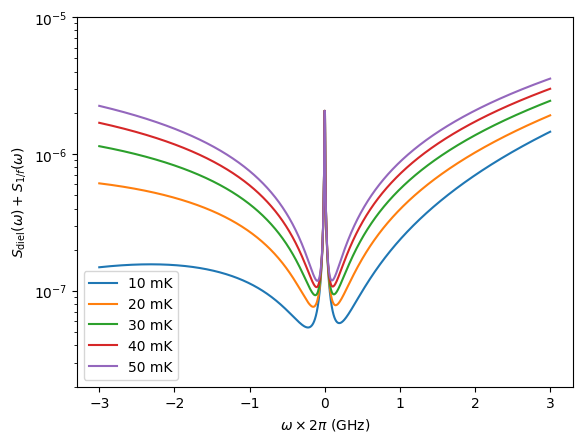

In [6]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 42 ):

    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    return_val = np.where(omega < 0, np.exp(-beta * hbar_in_eVs * 1e9 * -omega), 1.0)

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* 1e-6 * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val *=   1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) 
    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)



temp_list = [10,20,30,40,50]
omega_array = np.linspace(-3,3,1000)

eta = 5e-5
EC = 3/8
EL = 3/30
for temp in temp_list:
    gamma_diel = diel_spectral_density(omega_array, EC,temp )
    gamma_one_over_f = one_over_f_spectral_density(omega_array, EL,eta)
    plt.plot(omega_array, gamma_diel+gamma_one_over_f,label = f"{temp} mK")

plt.ylim(2e-8,1e-5)
plt.yscale('log')
plt.xlabel(rf"$\omega \times 2\pi$ (GHz)")
plt.ylabel(rf"$S_\text{{diel}}(\omega)+S_{{1/f}}(\omega)$")
plt.legend()

In [2]:
EJ = 3
EJ_over_EL_list = np.linspace(20,45,51)
EJ_over_EC_list = np.linspace(2,12,101)
X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)

import pickle
with open('data_v4_large_inductance.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


hbar = 1/(2*np.pi)

def dielectric_loss_rate(omega, EC, phi_element, Q_cap):
    temp_in_mK = 42  # K
    kB = 8.617333262e-5  # eV K−1
    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    return_val = hbar * omega**2  # h*GHZ^2
    return_val /= (4 * EC * Q_cap)  # GHZ
    return_val *= phi_element**2  # GHZ

    hbar_in_eVs = 6.5821e-16  # eV s
    coth_arg = beta * hbar_in_eVs * omega / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val *= 1 / np.tanh(coth_arg)  # GHZ
    return return_val


def one_over_f_loss_rate(omega, EL, phi_element, one_over_f_flux_noise_amplitude):
    return_val = 8 * np.pi**3  # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val *= (phi_element)**2 / omega  # GHz
    return return_val


def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # Seems the unit here should be millisecond? Where did miss a 1e3?

def compute_lifetimes(one_over_f_flux_noise_amplitude, Q_cap):
    conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    for i in range(len(EJ_over_EL_list)):
        for j in range(len(EJ_over_EC_list)):
            EC = EJ / EJ_over_EC_list[j]
            EL = EJ / EJ_over_EL_list[i]

            # Conventional lifetimes
            omega_conventional = conventional_freq_array[i, j] * 2 * np.pi
            phi_conventional = conventional_phi_element_array[i, j]
            second_order_conventional = conventional_2nd_order_array[i, j]

            conventional_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_conventional, EC, phi_conventional, Q_cap)
            conventional_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_conventional, EL, phi_conventional, one_over_f_flux_noise_amplitude)
            conventional_dephasing_lifetime[i, j] = T_phi(second_order_conventional, one_over_f_flux_noise_amplitude)

            # Upside down 01 lifetimes
            omega_upside_down01 = upside_down_freq01_array[i, j] * 2 * np.pi
            phi_upside_down01 = upside_down_phi_element01_array[i, j]
            second_order_upside_down01 = upside_down_2nd_order_01_array[i, j]

            upside_down01_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down01, EC, phi_upside_down01, Q_cap)
            upside_down01_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down01, EL, phi_upside_down01, one_over_f_flux_noise_amplitude)
            upside_down01_dephasing_lifetime[i, j] = T_phi(second_order_upside_down01, one_over_f_flux_noise_amplitude)

            # Upside down 12 lifetimes
            omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
            phi_upside_down12 = upside_down_phi_element12_array[i, j]
            second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]

            upside_down12_dielectric_lifetime[i, j] = 1 / dielectric_loss_rate(omega_upside_down12, EC, phi_upside_down12, Q_cap)
            upside_down12_one_over_f_loss_lifetime[i, j] = 1 / one_over_f_loss_rate(omega_upside_down12, EL, phi_upside_down12, one_over_f_flux_noise_amplitude)
            upside_down12_dephasing_lifetime[i, j] = T_phi(second_order_upside_down12, one_over_f_flux_noise_amplitude)

    return {
        "conventional_dielectric_lifetime": conventional_dielectric_lifetime,
        "conventional_one_over_f_loss_lifetime": conventional_one_over_f_loss_lifetime,
        "conventional_dephasing_lifetime": conventional_dephasing_lifetime,
        "upside_down01_dielectric_lifetime": upside_down01_dielectric_lifetime,
        "upside_down01_one_over_f_loss_lifetime": upside_down01_one_over_f_loss_lifetime,
        "upside_down01_dephasing_lifetime": upside_down01_dephasing_lifetime,
        "upside_down12_dielectric_lifetime": upside_down12_dielectric_lifetime,
        "upside_down12_one_over_f_loss_lifetime": upside_down12_one_over_f_loss_lifetime,
        "upside_down12_dephasing_lifetime": upside_down12_dephasing_lifetime
    }

In [4]:
combinations = [[4e-6, 1e6],  # more 1/f, less dielectric loss 
                [2e-6, 5e5], 
                [1.4e-6, 2.5e5],
                [5e-7, 1e5]]

tot_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_dielectric_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_1overf_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

for amplitude, Q in combinations:
    lifetimes = compute_lifetimes(amplitude, Q)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        Tphi_results[catagory].append(dephasing_T)
        T1_results[catagory].append(T1_tot)
        T1_dielectric_results[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
        T1_1overf_results[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)

/tmp/ipykernel_3544/3343724582.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Adjust layout to minimize extra white space


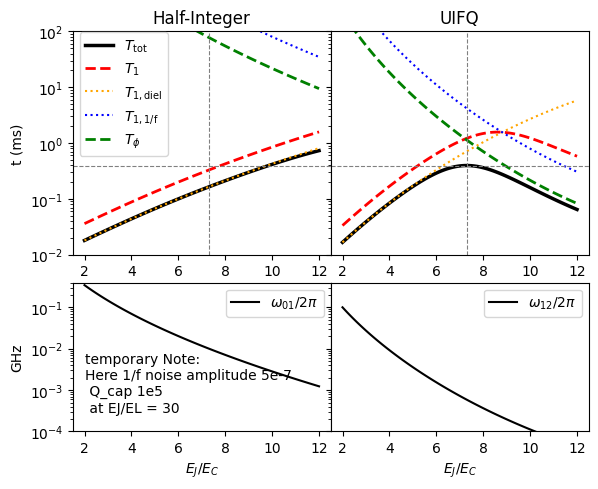

In [5]:
import matplotlib.pyplot as plt

# Assuming you have defined your data and variables before this snippet

fig = plt.figure(figsize=(6, 5))  # Adjusted total figure height

# Define gridspec with custom spacing and height ratios
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[3, 2], hspace=0.15, wspace=0.0, left=0.12, right=0.98, top=0.92, bottom=0.12)

# Axes for the first row
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]  # sharey ensures the same y-axis scale

# Axes for the second row
axes_row2 = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

EL_idx = 20
noise_profile_idx = -1

frequencys = {
    "conventional":conventional_freq_array,
    "upside_down12":upside_down_freq12_array
}
for i, (category, title) in enumerate(zip(["conventional", "upside_down12"],
                                          ['Half-Integer', 'UIFQ'])):
    for j, (results, name, color, line, width) in enumerate(zip([tot_results, T1_results, T1_dielectric_results, T1_1overf_results, Tphi_results],
                                                               [rf'$T_\text{{tot}}$', rf'$T_1$', rf'$T_{{1,\text{{diel}}}}$', rf'$T_{{1,\text{{1/f}}}}$', rf'$T_\phi$'],
                                                               ['black', 'red', 'orange', 'blue', 'green'],
                                                               ['solid', 'dashed', 'dotted', 'dotted', 'dashed'],
                                                               [2.5, 2, 1.5, 1.5, 2])):
        axes[i].plot(EJ_over_EC_list, results[category][noise_profile_idx][EL_idx, :], label=name, color=color, linestyle=line, linewidth=width)

    axes[i].set_yscale('log')
    axes[i].set_ylim(1e-2, 1e2)
    axes[i].set_title(title)
    # axes[i].set_xlabel(rf'$E_J/E_C$')
    if i == 0:
        axes[i].set_ylabel("t (ms)")

    line_y = max(tot_results['upside_down12'][noise_profile_idx][EL_idx, :])
    line_x = np.argmax(tot_results['upside_down12'][noise_profile_idx][EL_idx, :])
    axes[i].axhline(y=line_y, color='grey', linestyle='--',linewidth=0.8)
    axes[i].axvline(x=EJ_over_EC_list[line_x], color='grey', linestyle='--',linewidth=0.8)

for i, (category, name) in enumerate(zip(["conventional", "upside_down12"],
                                         [rf'$\omega_\text{{01}}/2\pi$',rf'$\omega_\text{{12}}/2\pi$'])):
    axes_row2[i].plot(EJ_over_EC_list, frequencys[category][EL_idx, :],label=name,color='black')
    axes_row2[i].set_ylim(1e-4, 4e-1)
    axes_row2[i].set_yscale('log')
    axes_row2[i].legend()
    axes_row2[i].set_xlabel(rf'$E_J/E_C$')
    if i == 0:
        axes_row2[i].set_ylabel("GHz")

# Remove yticks from the second subplot of the first row
plt.setp(axes[1].get_yticklabels(), visible=False)
plt.setp(axes_row2[1].get_yticklabels(), visible=False)

# Add legend to the first subplot with adjusted position
axes[0].legend(loc='center left', bbox_to_anchor=(0.0, 0.72))
axes_row2[0].text(2,3e-4,"temporary Note: \nHere 1/f noise amplitude 5e-7\n Q_cap 1e5\n at EJ/EL = 30")
# Now you can use axes_row2 for the second row plots later
plt.tight_layout()  # Adjust layout to minimize extra white space
plt.savefig('fig02_2d.pdf')
plt.show()


/tmp/ipykernel_3544/1426569293.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Adjust layout to minimize extra white space


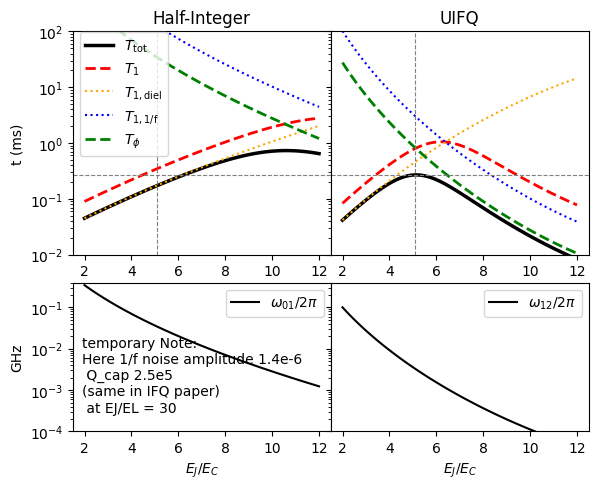

In [6]:
import matplotlib.pyplot as plt

# Assuming you have defined your data and variables before this snippet

fig = plt.figure(figsize=(6, 5))  # Adjusted total figure height

# Define gridspec with custom spacing and height ratios
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[3, 2], hspace=0.15, wspace=0.0, left=0.12, right=0.98, top=0.92, bottom=0.12)

# Axes for the first row
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]  # sharey ensures the same y-axis scale

# Axes for the second row
axes_row2 = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

EL_idx = 20
noise_profile_idx = -2

frequencys = {
    "conventional":conventional_freq_array,
    "upside_down12":upside_down_freq12_array
}
for i, (category, title) in enumerate(zip(["conventional", "upside_down12"],
                                          ['Half-Integer', 'UIFQ'])):
    for j, (results, name, color, line, width) in enumerate(zip([tot_results, T1_results, T1_dielectric_results, T1_1overf_results, Tphi_results],
                                                               [rf'$T_\text{{tot}}$', rf'$T_1$', rf'$T_{{1,\text{{diel}}}}$', rf'$T_{{1,\text{{1/f}}}}$', rf'$T_\phi$'],
                                                               ['black', 'red', 'orange', 'blue', 'green'],
                                                               ['solid', 'dashed', 'dotted', 'dotted', 'dashed'],
                                                               [2.5, 2, 1.5, 1.5, 2])):
        axes[i].plot(EJ_over_EC_list, results[category][noise_profile_idx][EL_idx, :], label=name, color=color, linestyle=line, linewidth=width)

    axes[i].set_yscale('log')
    axes[i].set_ylim(1e-2, 1e2)
    axes[i].set_title(title)
    # axes[i].set_xlabel(rf'$E_J/E_C$')
    if i == 0:
        axes[i].set_ylabel("t (ms)")
    line_y = max(tot_results['upside_down12'][noise_profile_idx][EL_idx, :])
    line_x = np.argmax(tot_results['upside_down12'][noise_profile_idx][EL_idx, :])
    axes[i].axhline(y=line_y, color='grey', linestyle='--',linewidth=0.8)
    axes[i].axvline(x=EJ_over_EC_list[line_x], color='grey', linestyle='--',linewidth=0.8)

for i, (category, name) in enumerate(zip(["conventional", "upside_down12"],
                                         [rf'$\omega_\text{{01}}/2\pi$',rf'$\omega_\text{{12}}/2\pi$'])):
    axes_row2[i].plot(EJ_over_EC_list, frequencys[category][EL_idx, :],label=name,color='black')
    axes_row2[i].set_ylim(1e-4, 4e-1)
    axes_row2[i].set_yscale('log')
    axes_row2[i].legend()
    axes_row2[i].set_xlabel(rf'$E_J/E_C$')
    if i == 0:
        axes_row2[i].set_ylabel("GHz")

# Remove yticks from the second subplot of the first row
plt.setp(axes[1].get_yticklabels(), visible=False)
plt.setp(axes_row2[1].get_yticklabels(), visible=False)








# Add legend to the first subplot with adjusted position
axes[0].legend(loc='center left', bbox_to_anchor=(0.0, 0.72))
axes_row2[0].text(1.9,3e-4,"temporary Note: \nHere 1/f noise amplitude 1.4e-6\n Q_cap 2.5e5\n(same in IFQ paper)\n at EJ/EL = 30")
# Now you can use axes_row2 for the second row plots later
plt.tight_layout()  # Adjust layout to minimize extra white space
plt.savefig('fig02_2d.pdf')
plt.show()
